In [ ]:
from deepface import DeepFace
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.metrics import root_mean_squared_error
import os
from sklearn.svm import SVR
from scipy.stats import pearsonr
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.neural_network import MLPRegressor
from keras.applications.vgg16 import VGG16
from keras.models import Model
from keras.layers import Flatten, Dense, Activation
import keras
from tensorflow.keras.utils import load_img, img_to_array
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.applications.resnet50 import ResNet50
from tensorflow.keras.utils import load_img, img_to_array


In [4]:
df = pd.read_csv("Data/clean_bmi_data.csv")
df.head()

,bmi,gender,is_training,name
0,34.207396,Male,1,img_0.bmp
1,26.453720,Male,1,img_1.bmp
2,34.967561,Female,1,img_2.bmp
3,22.044766,Female,1,img_3.bmp
4,25.845588,Female,1,img_6.bmp


In [5]:
df["image_path"] = df["name"].apply(lambda x: os.path.join("Data", "Images", f"{x}"))

# Basic VGG-Face Model

In [6]:
embeddings = []

for path in df["image_path"]:
    try:
        embedding_obj = DeepFace.represent(img_path = path, model_name = "VGG-Face", enforce_detection = False)
        embedding = embedding_obj[0]["embedding"]
    except Exception as e:
        print(f"Error processing {path}: {e}")
        embedding = np.zeros(2622)  
    embeddings.append(embedding)

X = np.array(embeddings)
y = df["bmi"].values

25-05-24 10:12:24 - vgg_face_weights.h5 will be downloaded...


Downloading...
From: https://github.com/serengil/deepface_models/releases/download/v1.0/vgg_face_weights.h5
To: /Users/hyunjikim/.deepface/weights/vgg_face_weights.h5
100%|██████████| 580M/580M [00:08<00:00, 72.4MB/s] 


In [7]:
#Read training and testing sets from data
train_mask = df["is_training"] == 1
test_mask = df["is_training"] == 0

#split
X_train = X[train_mask.values]
X_test = X[test_mask.values]
y_train = y[train_mask.values]
y_test = y[test_mask.values]


#tried PCA, did not improve results
#pca = PCA(n_components = 0.95)
#X_pca = pca.fit_transform(X)

#X_train = X_pca[train_mask.values]
#X_test = X_pca[test_mask.values]

In [8]:
ridge = Ridge()
ridge.fit(X_train, y_train)
y_pred_ridge = ridge.predict(X_test)

rmse_ridge = root_mean_squared_error(y_test, y_pred_ridge)
r_ridge, _ = pearsonr(y_test, y_pred_ridge)

print(f"Test RMSE Ridge: {rmse_ridge:.2f}")
print(f"Pearson r Ridge: {r_ridge:.2f}")

Test RMSE Ridge: 7.72
Pearson r Ridge: 0.55


In [9]:
#research paper from prof used gridsearch for their svr - ran it and got the best params, deleted gridsearch because it took so long
svr = SVR(kernel = 'rbf', C = 10, epsilon = 1.0, gamma = 'scale')
svr.fit(X_train, y_train)
y_pred_svr = svr.predict(X_test)

rmse_svr = root_mean_squared_error(y_test, y_pred_svr)
r_svr, _ = pearsonr(y_test, y_pred_svr)

print(f"Test RMSE SVR: {rmse_svr:.2f}")
print(f"Pearson r SVR: {r_svr:.2f}")

Test RMSE SVR: 7.70
Pearson r SVR: 0.57


In [10]:
rf = RandomForestRegressor(n_estimators = 100, random_state = 42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

rmse_rf = root_mean_squared_error(y_test, y_pred_rf)
r_rf, _ = pearsonr(y_test, y_pred_rf)

print(f"Test RMSE RF: {rmse_rf:.2f}")
print(f"Pearson r RF: {r_rf:.2f}")

Test RMSE RF: 7.90
Pearson r RF: 0.53


In [9]:
xgb = XGBRegressor(n_estimators = 100, learning_rate = 0.1, max_depth = 5, random_state = 42)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

rmse_xgb = root_mean_squared_error(y_test, y_pred_xgb)
r_xgb, _ = pearsonr(y_test, y_pred_xgb)

print(f"Test RMSE SVR: {rmse_xgb:.2f}")
print(f"Pearson r SVR: {r_xgb:.2f}")

Test RMSE SVR: 7.72
Pearson r SVR: 0.55


In [11]:
#mlp was best performing model, so also ran a gridsearch here - did not include it because it takes 40 minutes to run
mlp = MLPRegressor(hidden_layer_sizes = (512, 256, 64), activation = 'relu', solver = 'adam', alpha = 0.001, learning_rate = 'adaptive', max_iter = 500, random_state = 42)

mlp.fit(X_train, y_train)
y_pred_mlp = mlp.predict(X_test)

rmse_mlp = np.sqrt(root_mean_squared_error(y_test, y_pred_mlp))
r_mlp, _ = pearsonr(y_test, y_pred_mlp)

print(f"Test RMSE MLP: {rmse_mlp:.2f}")
print(f"Pearson r MLP: {r_mlp:.2f}")

Test RMSE MLP: 2.97
Pearson r MLP: 0.43


In [14]:
import joblib
joblib.dump(mlp, "best_model.joblib")

['best_model.joblib']

# Run Best Model (Above) with M/F Split Data

In [12]:
df_male = df[df["gender"] == "Male"]
df_female = df[df["gender"] == "Female"]

X_male = X[df["gender"] == "Male"]
X_female = X[df["gender"] == "Female"]

y_male = y[df["gender"] == "Male"]
y_female = y[df["gender"] == "Female"]


In [13]:
#male
train_mask_m = df_male["is_training"] == 1
test_mask_m = df_male["is_training"] == 0

X_train_m, X_test_m = X_male[train_mask_m.values], X_male[test_mask_m.values]
y_train_m, y_test_m = y_male[train_mask_m.values], y_male[test_mask_m.values]

#female
train_mask_f = df_female["is_training"] == 1
test_mask_f = df_female["is_training"] == 0

X_train_f, X_test_f = X_female[train_mask_f.values], X_female[test_mask_f.values]
y_train_f, y_test_f = y_female[train_mask_f.values], y_female[test_mask_f.values]

In [14]:
def run_mlp(X_train, y_train, X_test, y_test):
    mlp = MLPRegressor(hidden_layer_sizes=(512, 256, 64), activation='relu', solver='adam', alpha=0.001, learning_rate='adaptive', max_iter=500, random_state=42)
    mlp.fit(X_train, y_train)
    y_pred = mlp.predict(X_test)
    rmse = root_mean_squared_error(y_test, y_pred)
    r, _ = pearsonr(y_test, y_pred)
    return rmse, r

rmse_m, r_m = run_mlp(X_train_m, y_train_m, X_test_m, y_test_m)
rmse_f, r_f = run_mlp(X_train_f, y_train_f, X_test_f, y_test_f)

print(f"MLP (MALE) RMSE: {rmse_m:.2f}")
print(f"MLP (MALE) Pearson r: {r_m:.2f}")
print(f"MLP (FEMALE) RMSE: {rmse_f:.2f}")
print(f"MLP (FEMALE) Pearson r: {r_f:.2f}")

MLP (MALE) RMSE: 8.22
MLP (MALE) Pearson r: 0.49
MLP (FEMALE) RMSE: 9.12
MLP (FEMALE) Pearson r: 0.40


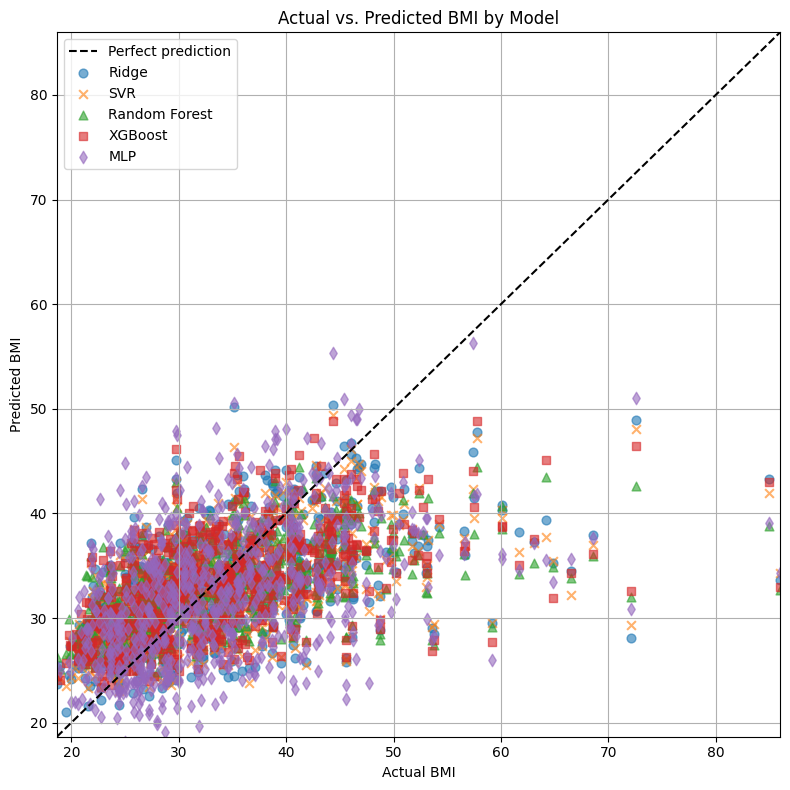

In [15]:
#visualize preds
plt.figure(figsize = (8, 8))

min_val = y_test.min()
max_val = y_test.max()
plt.plot([min_val, max_val], [min_val, max_val], 'k--', label = "Perfect prediction")

plt.scatter(y_test, y_pred_ridge, alpha = 0.6, label = "Ridge", s = 40, marker = 'o')
plt.scatter(y_test, y_pred_svr, alpha = 0.6, label = "SVR", s = 40, marker = 'x')
plt.scatter(y_test, y_pred_rf, alpha = 0.6, label = "Random Forest", s = 40, marker = '^')
plt.scatter(y_test, y_pred_xgb, alpha = 0.6, label = "XGBoost", s = 40, marker = 's')
plt.scatter(y_test, y_pred_mlp, alpha = 0.6, label = "MLP", s = 40, marker = 'd')

plt.xlabel("Actual BMI")
plt.ylabel("Predicted BMI")
plt.title("Actual vs. Predicted BMI by Model")
plt.legend()
plt.grid(True)
plt.xlim(min_val, max_val)
plt.ylim(min_val, max_val)
plt.tight_layout()
plt.show()

# fc6 Model

In [16]:
df = pd.read_csv("Data/clean_bmi_data.csv")
df.head()

,bmi,gender,is_training,name
0,34.207396,Male,1,img_0.bmp
1,26.453720,Male,1,img_1.bmp
2,34.967561,Female,1,img_2.bmp
3,22.044766,Female,1,img_3.bmp
4,25.845588,Female,1,img_6.bmp


In [17]:
df["image_path"] = df["name"].apply(lambda x: os.path.join("Data", "Images", f"{x}"))

In [18]:
# fc6 embeddings

base_model = VGG16(include_top=False, input_shape = (224, 224, 3))

x = base_model.output
x = Flatten(name = 'flatten')(x)
x = Dense(4096, activation = 'relu', name = 'fc6')(x)
x = Dense(4096, activation = 'relu', name = 'fc7')(x)
x = Dense(2622, activation = 'softmax', name = 'fc8')(x)

vggface_model = Model(inputs = base_model.input, outputs = x)

vggface_model.load_weights("rcmalli_vggface_tf_vgg16.h5", by_name = True)

fc6_model = Model(inputs=vggface_model.input, outputs = vggface_model.get_layer("fc6").output)


In [19]:
def extract_fc6_embedding(img_path, model):
    try:
        img = load_img(img_path, target_size=(224, 224))          
        x = img_to_array(img)                                     
        x = np.expand_dims(x, axis=0)
        x = preprocess_input(x)
        embedding = model.predict(x)[0]
        return embedding
    except Exception as e:
        print(f"Error processing {img_path}: {e}")
        return np.zeros(4096)


In [20]:
embeddings_fc6 = [extract_fc6_embedding(path, fc6_model) for path in df["image_path"]]
X = np.vstack(embeddings_fc6)  
y = df["bmi"].values

1/1 [==============================] - 0s 129ms/step


In [21]:
#Read training and testing sets from data
train_mask = df["is_training"] == 1
test_mask = df["is_training"] == 0

#split
X_train = X[train_mask.values]
X_test = X[test_mask.values]
y_train = y[train_mask.values]
y_test = y[test_mask.values]


In [22]:
ridge = Ridge()
ridge.fit(X_train, y_train)
y_pred_ridge = ridge.predict(X_test)

rmse_ridge = root_mean_squared_error(y_test, y_pred_ridge)
r_ridge, _ = pearsonr(y_test, y_pred_ridge)

print(f"Test RMSE Ridge: {rmse_ridge:.2f}")
print(f"Pearson r Ridge: {r_ridge:.2f}")

Test RMSE Ridge: 19.48
Pearson r Ridge: 0.22


In [23]:
#research paper from prof used gridsearch for their svr - ran it and got the best params, deleted gridsearch because it took so long
svr = SVR(kernel = 'rbf', C = 10, epsilon = 1.0, gamma = 'scale')
svr.fit(X_train, y_train)
y_pred_svr = svr.predict(X_test)

rmse_svr = root_mean_squared_error(y_test, y_pred_svr)
r_svr, _ = pearsonr(y_test, y_pred_svr)

print(f"Test RMSE SVR: {rmse_svr:.2f}")
print(f"Pearson r SVR: {r_svr:.2f}")

Test RMSE SVR: 8.69
Pearson r SVR: 0.39


In [24]:
rf = RandomForestRegressor(n_estimators = 100, random_state = 42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

rmse_rf = root_mean_squared_error(y_test, y_pred_rf)
r_rf, _ = pearsonr(y_test, y_pred_rf)

print(f"Test RMSE RF: {rmse_rf:.2f}")
print(f"Pearson r RF: {r_rf:.2f}")

Test RMSE RF: 8.99
Pearson r RF: 0.25


In [25]:
xgb = XGBRegressor(n_estimators = 100, learning_rate = 0.1, max_depth = 5, random_state = 42)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

rmse_xgb = root_mean_squared_error(y_test, y_pred_xgb)
r_xgb, _ = pearsonr(y_test, y_pred_xgb)

print(f"Test RMSE SVR: {rmse_xgb:.2f}")
print(f"Pearson r SVR: {r_xgb:.2f}")

Test RMSE SVR: 8.73
Pearson r SVR: 0.34


In [26]:
mlp = MLPRegressor(hidden_layer_sizes = (512, 256, 64), activation = 'relu', solver = 'adam', alpha = 0.001, learning_rate = 'adaptive', max_iter = 500, random_state = 42)

mlp.fit(X_train, y_train)
y_pred_mlp = mlp.predict(X_test)

rmse_mlp = np.sqrt(root_mean_squared_error(y_test, y_pred_mlp))
r_mlp, _ = pearsonr(y_test, y_pred_mlp)

print(f"Test RMSE MLP: {rmse_mlp:.2f}")
print(f"Pearson r MLP: {r_mlp:.2f}")

Test RMSE MLP: 3.39
Pearson r MLP: 0.14


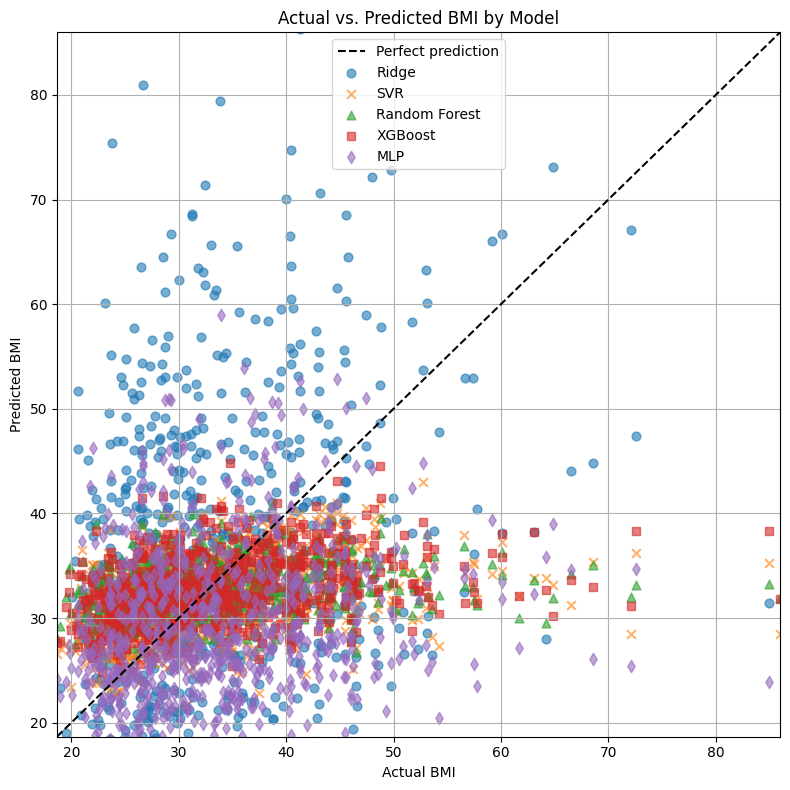

In [27]:
#visualize preds
plt.figure(figsize=(8, 8))

min_val = y_test.min()
max_val = y_test.max()
plt.plot([min_val, max_val], [min_val, max_val], 'k--', label = "Perfect prediction")

plt.scatter(y_test, y_pred_ridge, alpha = 0.6, label = "Ridge", s = 40, marker = 'o')
plt.scatter(y_test, y_pred_svr, alpha = 0.6, label = "SVR", s = 40, marker = 'x')
plt.scatter(y_test, y_pred_rf, alpha = 0.6, label = "Random Forest", s = 40, marker = '^')
plt.scatter(y_test, y_pred_xgb, alpha = 0.6, label = "XGBoost", s = 40, marker = 's')
plt.scatter(y_test, y_pred_mlp, alpha = 0.6, label = "MLP", s = 40, marker = 'd')

plt.xlabel("Actual BMI")
plt.ylabel("Predicted BMI")
plt.title("Actual vs. Predicted BMI by Model")
plt.legend()
plt.grid(True)
plt.xlim(min_val, max_val)
plt.ylim(min_val, max_val)
plt.tight_layout()
plt.show()

# ResNet Model

In [28]:
df = pd.read_csv("Data/clean_bmi_data.csv")
df.head()

,bmi,gender,is_training,name
0,34.207396,Male,1,img_0.bmp
1,26.453720,Male,1,img_1.bmp
2,34.967561,Female,1,img_2.bmp
3,22.044766,Female,1,img_3.bmp
4,25.845588,Female,1,img_6.bmp


In [29]:
df["image_path"] = df["name"].apply(lambda x: os.path.join("Data", "Images", x))

In [30]:
#ResNet embeddings
resnet_base = ResNet50(include_top = False, input_shape = (224, 224, 3), pooling = 'avg')  

x = resnet_base.output
x = Dense(2048, activation = 'relu', name = 'fc1')(x)
x = Dense(8631, name = 'classifier')(x)
x = Activation('softmax')(x)

resnet_model = Model(inputs=resnet_base.input, outputs=x)

resnet_model.load_weights("rcmalli_vggface_tf_resnet50.h5", by_name = True)

In [31]:
embedding_model = Model(inputs = resnet_model.input, outputs = resnet_model.get_layer("fc1").output)


In [32]:
def extract_resnet_embedding(img_path, model):
    try:
        img = load_img(img_path, target_size = (224, 224))
        x = img_to_array(img)
        x = np.expand_dims(x, axis = 0)
        x = preprocess_input(x)  
        embedding = model.predict(x)[0]
        return embedding
    except Exception as e:
        print(f"Error processing {img_path}: {e}")
        return np.zeros(2048)

In [33]:
embeddings_resnet = [extract_resnet_embedding(p, embedding_model) for p in df["image_path"]]
X = np.vstack(embeddings_resnet)
y = df["bmi"].values


1/1 [==============================] - 0s 256ms/step


In [34]:
#Read training and testing sets from data
train_mask = df["is_training"] == 1
test_mask = df["is_training"] == 0

#split
X_train = X[train_mask.values]
X_test = X[test_mask.values]
y_train = y[train_mask.values]
y_test = y[test_mask.values]


In [35]:
ridge = Ridge()
ridge.fit(X_train, y_train)
y_pred_ridge = ridge.predict(X_test)

rmse_ridge = root_mean_squared_error(y_test, y_pred_ridge)
r_ridge, _ = pearsonr(y_test, y_pred_ridge)

print(f"Test RMSE Ridge: {rmse_ridge:.2f}")
print(f"Pearson r Ridge: {r_ridge:.2f}")

Test RMSE Ridge: 11.52
Pearson r Ridge: 0.22


In [36]:
#research paper from prof used gridsearch for their svr - ran it and got the best params, deleted gridsearch because it took so long
svr = SVR(kernel = 'rbf', C = 10, epsilon = 1.0, gamma = 'scale')
svr.fit(X_train, y_train)
y_pred_svr = svr.predict(X_test)

rmse_svr = root_mean_squared_error(y_test, y_pred_svr)
r_svr, _ = pearsonr(y_test, y_pred_svr)

print(f"Test RMSE SVR: {rmse_svr:.2f}")
print(f"Pearson r SVR: {r_svr:.2f}")

Test RMSE SVR: 8.50
Pearson r SVR: 0.44


In [37]:
rf = RandomForestRegressor(n_estimators = 100, random_state = 42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

rmse_rf = root_mean_squared_error(y_test, y_pred_rf)
r_rf, _ = pearsonr(y_test, y_pred_rf)

print(f"Test RMSE RF: {rmse_rf:.2f}")
print(f"Pearson r RF: {r_rf:.2f}")

Test RMSE RF: 8.80
Pearson r RF: 0.32


In [38]:
xgb = XGBRegressor(n_estimators = 100, learning_rate = 0.1, max_depth = 5, random_state = 42)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

rmse_xgb = root_mean_squared_error(y_test, y_pred_xgb)
r_xgb, _ = pearsonr(y_test, y_pred_xgb)

print(f"Test RMSE SVR: {rmse_xgb:.2f}")
print(f"Pearson r SVR: {r_xgb:.2f}")

Test RMSE SVR: 8.73
Pearson r SVR: 0.35


In [39]:
mlp = MLPRegressor(hidden_layer_sizes = (512, 256, 64), activation = 'relu', solver = 'adam', alpha = 0.001, learning_rate = 'adaptive', max_iter = 500, random_state = 42)

mlp.fit(X_train, y_train)
y_pred_mlp = mlp.predict(X_test)

rmse_mlp = np.sqrt(root_mean_squared_error(y_test, y_pred_mlp))
r_mlp, _ = pearsonr(y_test, y_pred_mlp)

print(f"Test RMSE MLP: {rmse_mlp:.2f}")
print(f"Pearson r MLP: {r_mlp:.2f}")

Test RMSE MLP: 3.07
Pearson r MLP: 0.35


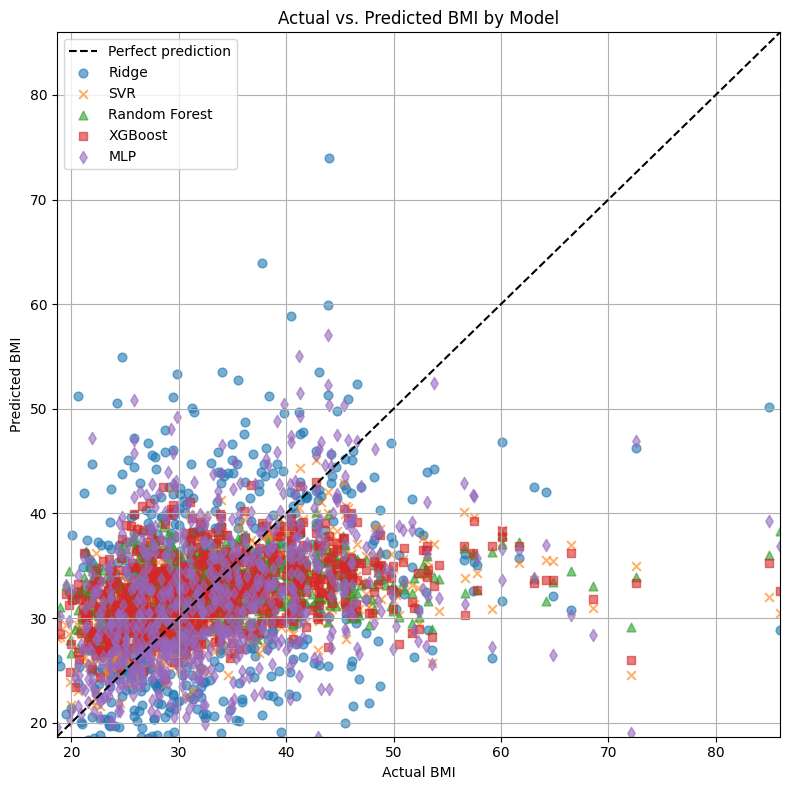

In [40]:
#visualize preds
plt.figure(figsize=(8, 8))

min_val = y_test.min()
max_val = y_test.max()
plt.plot([min_val, max_val], [min_val, max_val], 'k--', label = "Perfect prediction")

plt.scatter(y_test, y_pred_ridge, alpha = 0.6, label = "Ridge", s = 40, marker = 'o')
plt.scatter(y_test, y_pred_svr, alpha = 0.6, label = "SVR", s = 40, marker = 'x')
plt.scatter(y_test, y_pred_rf, alpha = 0.6, label = "Random Forest", s = 40, marker = '^')
plt.scatter(y_test, y_pred_xgb, alpha = 0.6, label = "XGBoost", s = 40, marker = 's')
plt.scatter(y_test, y_pred_mlp, alpha = 0.6, label = "MLP", s = 40, marker = 'd')

plt.xlabel("Actual BMI")
plt.ylabel("Predicted BMI")
plt.title("Actual vs. Predicted BMI by Model")
plt.legend()
plt.grid(True)
plt.xlim(min_val, max_val)
plt.ylim(min_val, max_val)
plt.tight_layout()
plt.show()